# Capstone — Early-Warning Queue for Organic Search Decline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashishpal003/flyrank_ml_intern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Author:** Ashish Pal  ·  **Lane:** Freestyle B — decline early-warning  ·  **Repo:** https://github.com/ashishpal003/flyrank_ml_intern

This notebook **mirrors the deployed research paper** (`docs/index.html`). It is **receipt-driven** — it re-reads the committed metric receipts under `work/outputs/*.json` and the figures under `work/figures/`, and reproduces every number the paper cites. **No warehouse, no token, no network** — a fresh clone runs it top-to-bottom in seconds. The heavy work is in `w01`–`w07`; this notebook is the story.

In [1]:
import json
from pathlib import Path

OUT = next(p for p in [Path('work/outputs'), Path('../outputs'), Path('outputs'), Path('../../work/outputs')] if p.is_dir())
FIG = next(p for p in [Path('work/figures'), Path('../figures'), Path('figures'), Path('../../work/figures')] if p.is_dir())
R = {name: json.loads((OUT / f'{name}.json').read_text()) for name in
     ['ml04_contract_checks', 'ml07_baseline_metrics', 'ml08_model_comparison',
      'ml09_validation_audit', 'ml10_playbook']}
print('loaded receipts:', list(R))
print('figures:', sorted(p.name for p in FIG.glob('*.png')))
print('all share seed 42; decision date 2026-03-01')

loaded receipts: ['ml04_contract_checks', 'ml07_baseline_metrics', 'ml08_model_comparison', 'ml09_validation_audit', 'ml10_playbook']
figures: ['fig1_precision_at_k.png', 'fig2_base_rate_drift.png']
all share seed 42; decision date 2026-03-01


## 1. Question

**The decision:** *which content pages should a FlyRank content strategist put on the refresh/review shortlist this cycle — before the traffic loss shows up in standard reporting?*

- **Unit of analysis:** one (content page × monthly decision date).
- **Output:** a ranked review queue with reason codes and a confidence tier — an *ordering of human attention*, not an edit and not an automated action.
- **Who acts:** the content strategist / editor for a client account, weekly, per client. They open the queue, read each page's recent trend, and decide the action themselves.
- **Cost of a wrong call:** a false alarm is ~1–2 wasted editor hours; a miss is weeks of undetected traffic loss and a harder recovery. Misses cost more, but review capacity is fixed — so the metric is **precision@K** reported next to the base rate.
- **Why ML at all:** near-future decline depends on the interaction of position drift, reach thinning, freshness, seasonality and traffic shape — many signals, tangled, and drifting over 17 months. A dashboard shows what happened; this orders *what's about to*.

In [2]:
c = R['ml04_contract_checks']
print('decision date  :', c['decision_date'])
print('feature window  :', c['feature_window'], ' (90 days before D)')
print('label window    :', c['label_window'], ' (30 days at/after D)')
print('metric          : precision@K (K = editor review budget), reported beside the base rate')

decision date  : 2026-03-01
feature window  : ['2025-12-01', '2026-03-01']  (90 days before D)
label window    : ['2026-03-01', '2026-03-31']  (30 days at/after D)
metric          : precision@K (K = editor review budget), reported beside the base rate


## 2. Data

**Source:** the FlyRank internship **warehouse** (`hf://datasets/FlyRank/internship-warehouse`) — pseudonymised daily search-performance data, queried in place with DuckDB (never downloaded).

**Scale & period:** ~78.8M daily fact rows, 104 clients, 519,606 content items, 2025-01-27 → 2026-06-30.

**Evaluation slice:** decision date **D = 2026-03-01**. Eligibility (ML-04): a page must have ≥ 100 search impressions in the prior 30 days, its client must have ≥ 90 days of history before D, and pages already in freefall are excluded (that is a recovery problem, out of scope). Funnel: **321,546 → 60,265** eligible pages.

**The label-quality fix (ML-08):** three clients stopped reporting after February, so every one of their pages had zero label-window impressions and was auto-labelled *declined* — panel dropout, not a real decline. Removing them drops the slice to **58,583 pages / 23 clients** and the base rate from **0.072 → 0.045**. This filter uses outcome-window information (a *churn-censoring* choice) — disclosed in Limitations.

**Excluded on purpose:** `trend_direction` / `trend_pct` / `is_declining_label` (the label is derived from them); any column whose window overlaps the label; FlyRank product flags (`health_score`, `priority_score`, `action_type`); `fact_content_query_90d` (its single 90-day window sits after every dev decision date); GA4 columns (only ~4% of rows carry real GA4 data). **Public-safe:** IDs are pseudonyms used for grouping only; no client names, URLs, page titles or raw queries anywhere in `work/`.

In [3]:
c = R['ml04_contract_checks']; lq = R['ml08_model_comparison']['label_quality']
print('warehouse row counts :', c['row_counts'], ' (match data dictionary:', c['row_counts_match'], ')')
print('grain duplicate keys :', c['grain_duplicate_keys'])
print('\neligibility funnel:')
for k, v in c['eligibility_funnel'].items():
    print(f'  {k:38} {v:>8,}')
print(f"  contaminated base rate                 {c['label_base_rate']:.4f}")
print('\nlabel-quality fix (ML-08):')
print(f"  dropout clients removed : {len(lq['dropout_clients_removed'])}  ({lq['rows_removed']:,} rows)")
print(f"  {lq['ml04_07_eligible_rows']:,} -> {R['ml08_model_comparison']['eligible_rows_cleaned']:,} pages   "
      f"| base rate {lq['ml04_07_base_rate']:.4f} -> {R['ml08_model_comparison']['base_rate']:.4f}")

warehouse row counts : {'dim_clients': 104, 'dim_content': 519606, 'fact_daily': 78835655, 'fact_query_90d': 2414248}  (match data dictionary: True )
grain duplicate keys : 0

eligibility funnel:
  content_in_feature_window               321,546
  after_volume_floor(imp_last30>=100)      81,521
  after_client_history(>=90d before D)     73,326
  after_exclude_freefall                   60,265
  contaminated base rate                 0.0717

label-quality fix (ML-08):
  dropout clients removed : 3  (1,682 rows)
  60,265 -> 58,583 pages   | base rate 0.0717 -> 0.0450


## 3. Methodology

**Task type.** A "which pages first?" **ranking** over a yes/no **observed** label — every model outputs a probability, we rank by it, and score the top K.

**Label.** `1` if the page's impressions over `[D, D+30d]` run ≥ 25% below its trailing-90-day pace **and** the second half of the label month is no higher than the first (a sustained decline, not a one-day spike).

**Baseline (ML-07), frozen.** A transparent hand-rule: `0.40·traffic_softening + 0.30·position_slip + 0.30·reach_thinning`, each a 0–1 percentile rank, no fitted weights. A fourth candidate — page visibility — was **dropped** because bigger pages declined *less* in this data.

**Models.** `DummyClassifier(prior)` → `LogisticRegression` → `DecisionTree(depth 3)` → `RandomForest` (configs mirror `scripts/03_train_model.py`; all `random_state=42`).

**Features (~39).** GSC feature-window aggregates (impressions, clicks, impression-weighted position, impression-days) + engineered ratios (softening ratio, position gap, reach ratio) + static `dim_content` metadata (age, word/char count, content type, competition), each with a `has_*` flag for content-type-linked missingness.

**Split.** **Grouped 5-fold on `client_hash_id`** (seed 42) — a client's pages never span train and test, so the model must generalise to clients it never saw.

**Leakage checks (ML-09).** Timeline drawn (every feature strictly before the label window); no product flags; a **planted-leak test** — adding the label-window column `imp_label` to the features and retraining moves average precision from 0.15 to 0.56 (the harness catches it, then the column is removed).

In [4]:
m8 = R['ml08_model_comparison']; la = R['ml09_validation_audit']['leakage_audit']
print('split         :', m8['split'], '| seed', m8['seed'])
print('libraries      :', m8['library_versions'])
print('label formula  : imp[D, D+30d] < 0.75 * (imp_90d/3)  AND  label-month 2nd half <= 1st half')
print('\nleakage audit:')
print('  banned columns in feature matrix       :', la['banned_columns_in_X'] or 'NONE')
print('  highest |corr(feature, label)|         :', la['top_feature_corr_with_label'][0])
print('  planted-leak avg precision honest -> +imp_label :',
      f"{la['planted_leak_avg_precision']['honest']} -> {la['planted_leak_avg_precision']['with_LEAK_imp_label']}",
      f"(delta +{la['planted_leak_avg_precision']['delta']})")

split         : grouped 5-fold CV on client_hash_id | seed 42
libraries      : {'scikit-learn': '1.9.0', 'numpy': '2.5.1', 'pandas': '3.0.5'}
label formula  : imp[D, D+30d] < 0.75 * (imp_90d/3)  AND  label-month 2nd half <= 1st half

leakage audit:
  banned columns in feature matrix       : NONE
  highest |corr(feature, label)|         : ['has_word_count', 0.112]
  planted-leak avg precision honest -> +imp_label : 0.15 -> 0.564 (delta +0.414)


## 4. Results (vs baseline)

**The frozen rule looked perfect and wasn't.** On the *contaminated* slice it scored precision@50 = **0.98** — but its top-50 was **98% one client's data dropout**. On the cleaned, client-grouped slice the same rule scores precision@50 ≈ **0.12**, average precision ≈ **0.09** — barely above random.

**The intuitive heuristic is worse than random.** Ranking by "biggest recent drop" scores average precision **below the base rate** in the development month — mean reversion.

**The learned models roughly double the rule** on grouped cross-validation (average precision **0.15** vs rule 0.09, random 0.08; ROC-AUC 0.61–0.64; per-client precision@10 0.24–0.27). Logistic regression ≈ random forest.

**Random split hides the truth.** The same random forest scores average precision 0.20 / ROC-AUC 0.81 under a *random* 5-fold split — and its fold-to-fold spread collapses. The gap is how much "skill" was really client memorisation.

**Sealed June 2026, read exactly once.** Base rate **0.345**. The random forest ranks at average precision **0.44** — clearly above random (0.34) and the frozen rule (0.39) — **but only level with the one-line heuristic (0.44)**.

In [5]:
m8 = R['ml08_model_comparison']; m9 = R['ml09_validation_audit']
print(f"GROUPED 5-FOLD CV, D = 2026-03-01   (base rate {m8['base_rate']})\n")
print(f"{'ranker':22}{'precision@50':>13}{'precision@5%':>13}{'avg_precision':>15}{'roc_auc':>9}{'per-client p@10':>16}")
for k, v in m8['comparison_table'].items():
    print(f"{k:22}{v['precision@50']['mean']:>13.3f}{v['precision@5%']['mean']:>13.3f}"
          f"{v['avg_precision']['mean']:>15.3f}{v['roc_auc']['mean']:>9.3f}{v['per_client_p@10']['mean']:>16.3f}")
print(f"\nrandom-forest overfit check: train avg precision {m8['random_forest_overfit_check']['train_avg_precision']}"
      f"  vs  out-of-fold {m8['random_forest_overfit_check']['oof_avg_precision']}")

print('\nRANDOM split vs GROUPED split (random forest):')
for r in m9['random_vs_grouped']:
    if r['model'] == 'random_forest':
        print(f"  {r['split']:8}  precision@50 {r['precision@50']:<18} avg_precision {r['avg_precision']:<18} roc_auc {r['roc_auc']}")

print('\nTIME-FORWARD (model trained once at D=2026-03-01, evaluated unchanged):')
for r in m9['walk_forward']:
    if r['ranker'] in ('random_forest', 'baseline_rule', 'naive_already_dipping'):
        print(f"  {r['D']}  {r['ranker']:22} base {r['base_rate']:.3f}  avg_precision {r['avg_precision']:.3f}  precision@5% {r['precision@5%']:.3f}")

print(f"\nSEALED JUNE 2026  (read once, in w06_validation_audit.ipynb cell-4c; base rate {m9['sealed_june_base_rate']}):")
for r in m9['sealed_june_2026']:
    print(f"  {r['ranker']:22} avg_precision {r['avg_precision']:.3f}  precision@5% {r['precision@5%']:.3f}  per-client p@10 {r['per_client_p@10']:.3f}")

GROUPED 5-FOLD CV, D = 2026-03-01   (base rate 0.045)

ranker                 precision@50 precision@5%  avg_precision  roc_auc per-client p@10
random                        0.064        0.077          0.081    0.499           0.133
stale_visible_rule            0.088        0.087          0.082    0.501           0.153
baseline_rule                 0.116        0.105          0.088    0.490           0.212
dummy_prior                   0.064        0.086          0.080    0.500           0.129
logistic_regression           0.228        0.224          0.150    0.612           0.236
decision_tree                 0.084        0.098          0.090    0.537           0.150
random_forest                 0.212        0.217          0.152    0.643           0.269

random-forest overfit check: train avg precision 0.3286  vs  out-of-fold 0.152

RANDOM split vs GROUPED split (random forest):
  random    precision@50 0.396 [0.26,0.46]  avg_precision 0.199 [0.17,0.22]  roc_auc 0.808 [0.79,0.83]
  

## 5. Limitations

- **Churn-censored population.** Clients absent from a label month are dropped. The queue describes *surviving* portfolios; it says nothing about a client mid-offboarding. This exclusion uses outcome-window information — a deliberate choice, stated here.
- **GSC-visible, above-floor pages only.** A page needs ≥ 100 impressions / 30 d to enter. **Absence from the queue is not evidence a page is healthy.**
- **One content operation, one ~17-month snapshot, no causal design.** Nothing here shows that refreshing a flagged page changes its outcome.
- **The label base rate is not stationary** — 0.045 → 0.219 → 0.198 → 0.345 across four months, because it tracks the panel-wide impressions trend. So `precision@K` is **not comparable across months**, and the score is **not a calibrated probability**.
- **Wide per-client / per-fold variance.** Per-fold precision@50 spans 0.04 to 0.50; the queue works well for some client books and barely at all for others.
- **One walk-forward direction and one sealed month.** A longer multi-window backtest is the highest-value missing experiment.

In [6]:
m9 = R['ml09_validation_audit']
print('label base rate by month (non-stationary):')
for mth, br in m9['label_non_stationary']['base_rate_by_month'].items():
    print(f'  {mth}   {br}')
print('\nper-fold precision@50 spread (grouped CV, logistic_regression):',
      R['ml08_model_comparison']['comparison_table']['logistic_regression']['precision@50'])
print('population note:', m9['population_note'])

label base rate by month (non-stationary):
  2026-03   0.045
  2026-04   0.219
  2026-05   0.198
  2026-06   0.345

per-fold precision@50 spread (grouped CV, logistic_regression): {'mean': 0.228, 'min': 0.04, 'max': 0.5}
population note: churn-censored: clients with zero rows in a label month are excluded (ML-08 label-quality gate). GSC-visible pages with imp_last30 >= 100 only.


## 6. Ranked recommendations

The output is the **ML-10 action playbook** — a queue of all 58,583 eligible pages, scored by `final_score = 100·(0.70·model_out-of-fold_score + 0.30·frozen-rule_percentile)`. It is a **model score, not a probability**.

- **Every row carries reason codes** (rule + model + two policy codes) and a **suggested action** (`refresh` / `review_position` / `review_metadata` / `monitor` / `monitor_only` / `watchlist`).
- **Three confidence tiers.** `high` is deliberately hard to earn — only ~1.4% of pages clear it.
- **Two policy holds baked in from the error analysis:** `durable_riser_hold` (traffic is actually rising → never refresh) and `low_volume_position_only` (position noise on a small page → watchlist). About a third of the top 50 are held for human judgement.
- **An 8-item no-go list** — never auto-edit, never call the score a probability, never claim a refresh prevents a decline, never run the queue while the drift alarm is tripped, …
- **Monitoring:** an outcome-drift alarm (recompute the label base rate monthly vs 0.045) that **trips in 3 of 4 months**, and a PSI feature-drift harness (`content_age_days`, the model's top feature, shows major drift by May).

**Verdict:** *the evidence supports testing this ordering as decision support; it does not support automating actions.*

In [7]:
p = R['ml10_playbook']
print('queue rows        :', f"{p['queue_rows']:,}", ' | base rate', p['base_rate'])
print('action mix        :', p['queue_summary']['action_mix'])
print('confidence mix    :', p['queue_summary']['confidence_mix'])
print('top-20 OOF hit rate:', p['queue_summary']['top20_oof_hit_rate'],
      ' | top-50 held for human judgement:', p['queue_summary']['top50_held_for_human_judgement'])
print('\nno-go list:')
for i, g in enumerate(p['no_go_list'], 1):
    print(f'  {i}. {g}')
print('\noutcome-drift alarm:')
for d in p['monitoring']['outcome_drift_alarm']:
    print(f"  {d['month']:26} base {d['base_rate']:.3f}   ALARM = {d['ALARM']}")
print('\nPSI feature drift (Mar->May):')
for row in p['monitoring']['psi_feature_drift']:
    print(f"  {row['feature']:18} {row['PSI Mar->May']:.3f}")

queue rows        : 58,583  | base rate 0.045
action mix        : {'monitor_only': 31944, 'monitor': 20885, 'review_position': 5637, 'watchlist': 71, 'refresh': 43, 'review_metadata': 3}
confidence mix    : {'low': 29290, 'medium': 28489, 'high': 804}
top-20 OOF hit rate: 0.25  | top-50 held for human judgement: 15

no-go list:
  1. never auto-edit or auto-publish; every row keeps a human accept/reject
  2. never refresh a durable_riser_hold
  3. never act on low_volume_position_only on position alone
  4. never present the score as "this page will decline"
  5. never claim a refresh prevents decline
  6. never rank across clients without per-client context
  7. never run the queue while the base-rate alarm is tripped without re-review
  8. never call final_score a probability (calibration not evaluated)

outcome-drift alarm:
  2026-03                    base 0.045   ALARM = False
  2026-04                    base 0.219   ALARM = True
  2026-05                    base 0.198   ALARM = T

## 7. Artifacts the paper embeds

The deployed paper (`docs/index.html`) shows two figures and a result-to-notebook map. Both figures are generated by `w07_action_playbook.ipynb`'s exports cell; the paper cites the **sealed-June** numbers from `work/outputs/ml09_validation_audit.json` and does **not** re-read the sealed month.

*(Figures and the traceability table below.)*

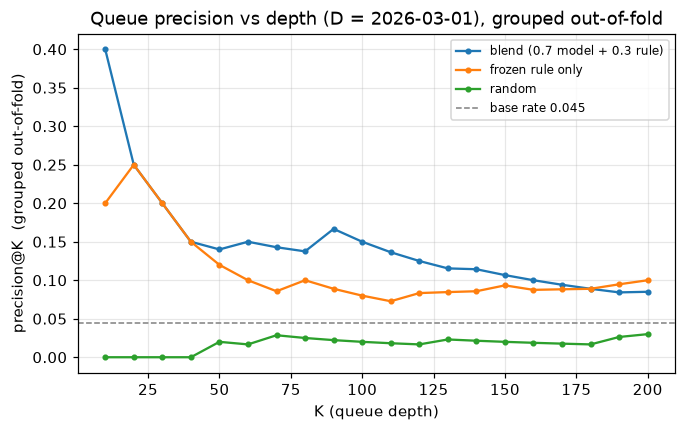

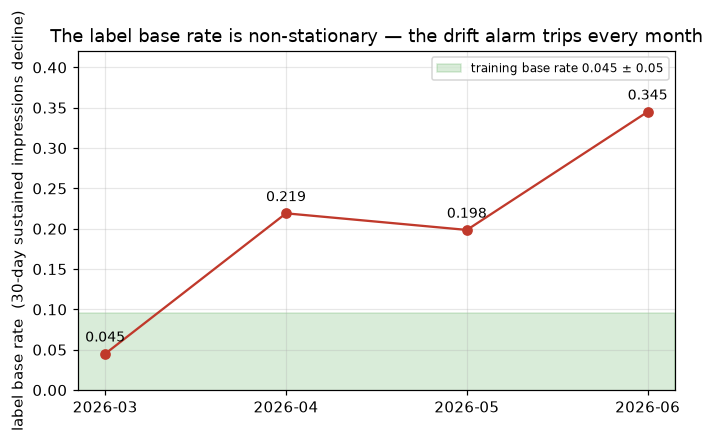

RESULT -> NOTEBOOK MAP (every reported number regenerates from a committed receipt):

  data contract / eligibility funnel                    w03_data_contract.ipynb  ->  ml04_contract_checks.json
  frozen baseline metrics                               w04_baseline_score.ipynb  ->  ml07_baseline_metrics.json
  grouped 5-fold model comparison                       w05_model.ipynb  ->  ml08_model_comparison.json
  random-vs-grouped, walk-forward, sealed June          w06_validation_audit.ipynb (cell-4c reads June once)  ->  ml09_validation_audit.json
  Figure 1 (precision@K) + Figure 2 (base-rate drift)   w07_action_playbook.ipynb exports cell  ->  work/figures/*.png
  action queue + playbook                               w07_action_playbook.ipynb final cell  ->  ml10_playbook.json (+ gitignored queue CSV)


In [8]:
from IPython.display import Image, display
display(Image(filename=str(FIG / 'fig1_precision_at_k.png')))
display(Image(filename=str(FIG / 'fig2_base_rate_drift.png')))

print('RESULT -> NOTEBOOK MAP (every reported number regenerates from a committed receipt):\n')
rows = [
    ('data contract / eligibility funnel', 'w03_data_contract.ipynb  ->  ml04_contract_checks.json'),
    ('frozen baseline metrics',            'w04_baseline_score.ipynb  ->  ml07_baseline_metrics.json'),
    ('grouped 5-fold model comparison',    'w05_model.ipynb  ->  ml08_model_comparison.json'),
    ('random-vs-grouped, walk-forward, sealed June', 'w06_validation_audit.ipynb (cell-4c reads June once)  ->  ml09_validation_audit.json'),
    ('Figure 1 (precision@K) + Figure 2 (base-rate drift)', 'w07_action_playbook.ipynb exports cell  ->  work/figures/*.png'),
    ('action queue + playbook',            'w07_action_playbook.ipynb final cell  ->  ml10_playbook.json (+ gitignored queue CSV)'),
]
for a, b in rows:
    print(f'  {a:52}  {b}')

## ML-12 — 5-minute demo outline

1. **The decision (30s).** "An editor has time to review 50 pages a week per client. Which 50, and in what order?"
2. **The data (30s).** FlyRank's warehouse — ~79M daily search rows, 104 clients, 17 months. Queried in place, never downloaded.
3. **The honest baseline (45s).** A transparent hand-rule scored precision@50 = 0.98 — until we found 98% of its top-50 was one client's data dropout. On the cleaned, client-grouped slice: 0.12. And ranking by "biggest recent drop" is *worse than random* — mean reversion.
4. **The model (45s).** Logistic regression / random forest, grouped 5-fold by client, ~39 pre-decision features, a planted-leak stress test. Roughly doubles the rule (avg precision 0.15 vs 0.09).
5. **The blind month (60s).** June 2026, opened once. The model beats random and the rule (avg precision 0.44 vs 0.34 / 0.39) — but ties a one-line heuristic, and the base rate had moved from 0.045 to 0.345.
6. **The playbook (45s).** Reason codes, confidence tiers, two policy holds, an 8-item no-go list, a monthly drift alarm that trips 3 of 4 months.
7. **The verdict (15s).** Test the ordering as decision support. Do not automate actions.

## ML-12 — social-post cut

> Ranking web pages by "biggest recent traffic drop" to decide what to fix first? On 17 months of real search data (104 clients, ~79M rows) that heuristic scored **below random** — it's mean reversion.
>
> A client-grouped, leakage-audited ranker that weighs position drift + reach thinning + softening traffic *together* does modestly better (avg precision 0.15 vs 0.09 for a hand-rule), and on one sealed month it beat both a frozen rule and random — but only tied a one-liner, and the label's base rate swung 0.045 → 0.345 in four months.
>
> Honest take: worth testing as a **review-queue order**, not as automation — and only with a monthly base-rate check. Method + notebooks: github.com/ashishpal003/flyrank_ml_intern

*(pair with `work/figures/fig2_base_rate_drift.png` — the non-stationary base rate is the single most surprising result.)*

## ML-12 — 3-sentence employer summary

I built a client-grouped, leakage-audited ranker that orders a monthly content-review queue for organic-search decline, on FlyRank's ~79M-row search warehouse (104 pseudonymised clients, 17 months), with a frozen hand-rule as the baseline to beat. Under grouped 5-fold cross-validation and a single blind month (June 2026, read once), the model beat the hand-rule and random ordering on average precision (0.44 vs 0.39 and 0.34 on the sealed month), though it only tied a one-line heuristic and the label's base rate proved non-stationary across months. The deliverable is an action playbook — ranked queue, reason codes, confidence tiers, an 8-item no-go list and a drift-alarm monitor — with the honest conclusion that the ordering is worth testing as decision support but automating actions is not supported.

## Self-check

- [x] Every section filled — markdown reasoning AND the code that backs it (receipt-driven; runs offline, no warehouse/token)
- [x] Runs top to bottom with no errors; every code cell carries output
- [x] No client names, URLs, or private queries anywhere; IDs shown are pseudonyms
- [x] Claims use careful words: observed / measured / directional / decision-support; base rate printed next to every precision@K
- [x] Committed under `work/notebooks/`
- [x] Deployed paper (`docs/index.html`) carries **all 9 sections** — Abstract at the top, Acknowledgments & data credit (the https://flyrank.ai link) at the bottom
- [x] **ML-12 done** in the closing cells above: 5-minute demo outline + social-post cut + 3-sentence employer summary
- [ ] `submission/paper_url.txt` updated with the deployed URL after GitHub Pages is live